**Dataset**
labeled datasset collected from twitter (Lab 1 - Hate Speech.tsv)

**Objective**
classify tweets containing hate speech from other tweets. <br>
0 -> no hate speech <br>
1 -> contains hate speech <br>

**Total Estimated Time = 90-120 Mins**

**Evaluation metric**
macro f1 score

### Import used libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 500)

### Load Dataset

###### Note: search how to load the data from tsv file

In [ ]:
df = pd.read_csv("Lab 1 - Hate Speech.tsv", sep="\t")
df.head(100)

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run
1,2,0,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in urð±!!! ðððð ð¦ð¦ð¦
4,5,0,factsguide: society now #motivation
5,6,0,[2/2] huge fan fare and big talking before they leave. chaos and pay disputes when they get there. #allshowandnogo
6,7,0,@user camping tomorrow @user @user @user @user @user @user @user dannyâ¦
7,8,0,the next school year is the year for exams.ð¯ can't think about that ð­ #school #exams #hate #imagine #actorslife #revolutionschool #girl
8,9,0,we won!!! love the land!!! #allin #cavs #champions #cleveland #clevelandcavaliers â¦
9,10,0,@user @user welcome here ! i'm it's so #gr8 !


### Data splitting

It is a good practice to split the data before EDA helps maintain the integrity of the machine learning process, prevents data leakage, simulates real-world scenarios more accurately, and ensures reliable model performance evaluation on unseen data.

In [ ]:
X = df['tweet']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {len(X_train):,}")
print(f"Test set size     : {len(X_test):,}")

Training set size : 25,228
Test set size     : 6,307


### EDA on training data

- check NaNs

In [ ]:
train_df = pd.DataFrame({'tweet': X_train, 'label': y_train})

print("Missing values per column:")
print(train_df.isnull().sum())
print(f"\nTotal NaN cells: {train_df.isnull().sum().sum()}")

Missing values per column:
tweet    0
label    0
dtype: int64

Total NaN cells: 0


- check duplicates

In [ ]:
num_duplicates = train_df.duplicated(subset='tweet').sum()
print(f"Number of duplicate tweets in training set: {num_duplicates}")

if num_duplicates > 0:
    print("\nSample duplicates:")
    print(train_df[train_df.duplicated(subset='tweet', keep=False)].head(6))

Number of duplicate tweets in training set: 1795

Sample duplicates:
                                                                                                               tweet  \
21425   #rainbowrowell   bull up: you will dominate your bull and you will direct it whatever you want it to do. whe   
18766                                                                   i am adventure. #i_am #positive #affirmation   
9215   mrrat395:   #starfightersaturday phantomaviation cptplanespotter blackmaverick12 wbruchal ufeellucky spad5â¦   
754                                                         life is what you make it. letâs make it  ! #motivation   
5595                            #model   i love u take with u all the time in urð±!!! ððððð¦ð¦ð¦   
26418                                                   foods for #healing your body!!    #doplants! #healthy is  !!   

       label  
21425      0  
18766      0  
9215       0  
754        0  
5595       0  


- show a representative sample of data texts to find out required preprocessing steps

In [6]:
print("=== Sample of NON-HATE tweets (label=0) ===")
print(train_df[train_df['label'] == 0]['tweet'].sample(5, random_state=42).to_string(index=False))

print("\n=== Sample of HATE tweets (label=1) ===")
print(train_df[train_df['label'] == 1]['tweet'].sample(5, random_state=42).to_string(index=False))

=== Sample of NON-HATE tweets (label=0) ===
                                                                     quotestags_app #life   #down #people  #quote #quotestags
                               fasted walk done, healthy breakfast and a run later :) #lifestyle #health #fitness #choices   
          would this affect england's playing ability ? #euro2016 despite appeals english fans still causing probs   ð¬ð§
                                    greek pasta salad recipe  #salad #pasta #food #yummy #foodie #delicious   #instagood #â¦
@user thank you for the  too :)i hope your weekend has been great also, it's a busy one this end,all good though.   #sunday x

=== Sample of HATE tweets (label=1) ===
                                the latest obsidian radio daily!  thanks to @user @user @user  #latesnews
        @user #feminismiscancer #feminismisterrorism #feminismmuktbharat why  #malevote is ignored  @user
                                     crooked hillary clinton hates black 

- check dataset balancing

Label distribution in training set:
  Label 0 (No Hate): 23,458 (93.0%)
  Label 1 (Hate Speech): 1,770 (7.0%)

Imbalance ratio (majority/minority): 13.3x


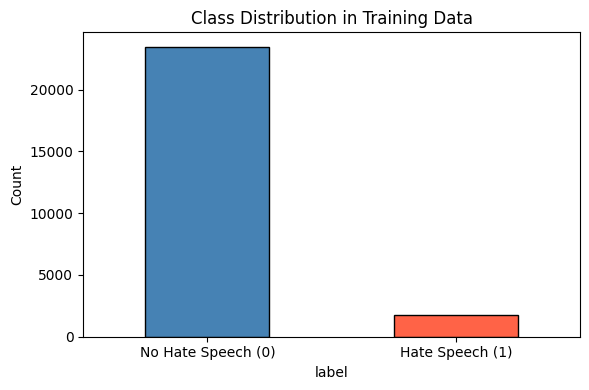


Conclusion: Dataset is HIGHLY IMBALANCED (~13:1 ratio).
This makes macro F1 score the right metric — accuracy alone would be misleading.


In [7]:
class_counts = train_df['label'].value_counts()
class_pct = train_df['label'].value_counts(normalize=True) * 100

print("Label distribution in training set:")
for label in [0, 1]:
    print(f"  Label {label} ({'No Hate' if label == 0 else 'Hate Speech'}): "
          f"{class_counts[label]:,} ({class_pct[label]:.1f}%)")

print(f"\nImbalance ratio (majority/minority): {class_counts[0] / class_counts[1]:.1f}x")

# Bar chart
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.xticks([0, 1], ['No Hate Speech (0)', 'Hate Speech (1)'], rotation=0)
plt.title('Class Distribution in Training Data')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("\nConclusion: Dataset is HIGHLY IMBALANCED (~13:1 ratio).")
print("This makes macro F1 score the right metric — accuracy alone would be misleading.")

- Cleaning and Preprocessing are:
    - 1. Lowercase all text
    - 2. Remove @user mentions (not informative)
    - 3. Remove URLs
    - 4. Remove '#' symbol (keep the hashtag word)
    - 5. Remove non-alphabetic characters (punctuation, numbers, emojis/unicode artifacts)
    - 6. Strip extra whitespace

### Cleaning and Preprocessing

#### Extra: use custom scikit-learn Transformers

Using custom transformers in scikit-learn provides flexibility, reusability, and control over the data transformation process, allowing you to seamlessly integrate with scikit-learn's pipelines, enabling you to combine multiple preprocessing steps and modeling into a single workflow. This makes your code more modular, readable, and easier to maintain.

##### link: https://www.andrewvillazon.com/custom-scikit-learn-transformers/

#### Example usage:

In [22]:
class CustomTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, parameter1, parameter2):
        self.parameter1 = parameter1
        self.parameter2 = parameter2

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        transformed_X = X.copy()
        transformed_X['feature1'] = transformed_X['feature1'] * self.parameter1
        transformed_X['feature2'] = transformed_X['feature2'] * self.parameter2
        return transformed_X

    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.transform(X)

In [24]:
class TweetPreprocessor(BaseEstimator, TransformerMixin):
    """
    Custom scikit-learn transformer that cleans raw tweet text.
    Steps:
      1. Lowercase
      2. Remove @mentions
      3. Remove URLs
      4. Remove '#' symbol (keep hashtag words)
      5. Remove non-alphabetic characters
      6. Collapse whitespace
    """

    def fit(self, X, y=None):
        return self  # stateless transformer

    def transform(self, X):
        return pd.Series(X).apply(self._clean)

    @staticmethod
    def _clean(text):
        text = str(text).lower()                          # 1. lowercase
        text = re.sub(r'@\w+', '', text)                  # 2. remove @mentions
        text = re.sub(r'http\S+|www\S+', '', text)        # 3. remove URLs
        text = re.sub(r'#', '', text)                     # 4. remove # symbol
        text = re.sub(r'[^a-z\s]', '', text)              # 5. remove non-alpha
        text = re.sub(r'\s+', ' ', text).strip()          # 6. strip whitespace
        return text


In [10]:
# Preview cleaned training text
cleaned_sample = preprocessor.transform(X_train.head(10))
for orig, clean in zip(X_train.head(10), cleaned_sample):
    print(f"ORIGINAL : {orig[:80]}")
    print(f"CLEANED  : {clean[:80]}")
    print()

ORIGINAL :  @user @user would like to wish you a   #father's day :),  #family #dad #fathers
CLEANED  : would like to wish you a fathers day family dad fathersday

ORIGINAL : always enjoy life! and be grateful for what you have #mondaymotivation #2016
CLEANED  : always enjoy life and be grateful for what you have mondaymotivation

ORIGINAL : kayak, sup, snorkel, swim...whatever your pleasure, we'll put it together!  #alo
CLEANED  : kayak sup snorkel swimwhatever your pleasure well put it together alohabeachbus 

ORIGINAL : @user what do you think of #alexjones saying #draintheswamp? #populationcontrol 
CLEANED  : what do you think of alexjones saying draintheswamp populationcontrol you had go

ORIGINAL : well i guess i can't join servers mcpe 15.0. #mcpe    #mcpc #weird
CLEANED  : well i guess i cant join servers mcpe mcpe mcpc weird

ORIGINAL : trumps associates are a classy bunch.
CLEANED  : trumps associates are a classy bunch

ORIGINAL : now playing #intwine -   on classic rock atti

### Modelling

#### Extra: use scikit-learn pipline

##### link: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

Using pipelines in scikit-learn promotes better code organization, reproducibility, and efficiency in machine learning workflows.

#### Example usage:

In [ ]:
from sklearn.pipeline import Pipeline

model = LogisticRegression()

pipeline = Pipeline(steps=[
    ('preprocessing', TweetPreprocessor()),
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('model', model),
])


In [ ]:
# ---------------------------------------------------------------
# Baseline Pipeline:
#   TweetPreprocessor -> TF-IDF (unigrams + bigrams) -> Logistic Regression
#
# class_weight='balanced' handles the ~13:1 class imbalance automatically
# ---------------------------------------------------------------

baseline_pipeline = Pipeline(steps=[
    ('preprocessing', TweetPreprocessor()),
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50_000,
        sublinear_tf=True       
    )),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

baseline_pipeline.fit(X_train, y_train)
print("Baseline pipeline trained successfully.")

Baseline pipeline trained successfully.


#### Evaluation

**Evaluation metric:**
macro f1 score

Macro F1 score is a useful metric in scenarios where you want to evaluate the overall performance of a multi-class classification model, **particularly when the classes are imbalanced**

![Calculation](https://assets-global.website-files.com/5d7b77b063a9066d83e1209c/639c3d934e82c1195cdf3c60_macro-f1.webp)

In [ ]:
def evaluate(name, y_true, y_pred):
    """Print evaluation summary for a model."""
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{'='*50}")
    print(f"Model : {name}")
    print(f"Macro F1 Score: {macro_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=['No Hate (0)', 'Hate Speech (1)']))
    return macro_f1

baseline_f1 = evaluate("Baseline (Unigrams+Bigrams, LR)", y_test)

Model : Baseline (Unigrams+Bigrams, LR)
Macro F1 Score: 0.8258

Classification Report:
                 precision    recall  f1-score   support

    No Hate (0)       0.98      0.96      0.97      5864
Hate Speech (1)       0.60      0.78      0.68       443

       accuracy                           0.95      6307
      macro avg       0.79      0.87      0.83      6307
   weighted avg       0.96      0.95      0.95      6307



### Enhancement

- Using different N-grams
- Using different text representation technique
- Hyperparameter tuning

In [ ]:
enhanced_pipeline = Pipeline(steps=[
    ('preprocessing', TweetPreprocessor()),
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),       
        max_features=80_000,
        sublinear_tf=True,
        min_df=2                 
    )),
    ('clf', LogisticRegression(
        class_weight='balanced',
        C=5,                      
        max_iter=1000,
        random_state=42
    ))
])

enhanced_pipeline.fit(X_train, y_train)
y_pred_enhanced = enhanced_pipeline.predict(X_test)
enhanced_f1 = evaluate("Enhanced (Trigrams, C=5)", y_test, y_pred_enhanced)

Model : Enhanced (Trigrams, C=5)
Macro F1 Score: 0.8413

Classification Report:
                 precision    recall  f1-score   support

    No Hate (0)       0.98      0.98      0.98      5864
Hate Speech (1)       0.70      0.71      0.70       443

       accuracy                           0.96      6307
      macro avg       0.84      0.84      0.84      6307
   weighted avg       0.96      0.96      0.96      6307



In [ ]:
char_pipeline = Pipeline(steps=[
    ('preprocessing', TweetPreprocessor()),
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(3, 5),
        max_features=80_000,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

char_pipeline.fit(X_train, y_train)
y_pred_char = char_pipeline.predict(X_test)
char_f1 = evaluate("Character n-grams (3-5)", y_test, y_pred_char)

Model : Character n-grams (3-5)
Macro F1 Score: 0.8138

Classification Report:
                 precision    recall  f1-score   support

    No Hate (0)       0.99      0.95      0.97      5864
Hate Speech (1)       0.55      0.82      0.66       443

       accuracy                           0.94      6307
      macro avg       0.77      0.88      0.81      6307
   weighted avg       0.96      0.94      0.95      6307



In [ ]:
results = {
    'Baseline (1-2 grams)':   baseline_f1,
    'Enhanced (1-3 grams)':   enhanced_f1,
    'Char n-grams (3-5)':     char_f1,
}

print("\n=== Final Model Comparison ===")
for name, score in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name:<28} | Macro F1: {score:.4f} ")


=== Final Model Comparison ===
Enhanced (1-3 grams)         | Macro F1: 0.8413 
Baseline (1-2 grams)         | Macro F1: 0.8258 
Char n-grams (3-5)           | Macro F1: 0.8138 


### Conclusion and final results


In [ ]:
# Final evaluation on the test set
y_pred_final = best_pipeline.predict(X_test)

print("Final Classification Report:")
print(classification_report(y_test, y_pred_final,
                            target_names=['No Hate (0)', 'Hate Speech (1)']))
print(f"Final Macro F1 Score: {f1_score(y_test, y_pred_final, average='macro'):.4f}")

Final Classification Report:
                 precision    recall  f1-score   support

    No Hate (0)       0.98      0.98      0.98      5864
Hate Speech (1)       0.70      0.71      0.70       443

       accuracy                           0.96      6307
      macro avg       0.84      0.84      0.84      6307
   weighted avg       0.96      0.96      0.96      6307

Final Macro F1 Score: 0.8413
